In [1]:
import numpy as np

import matplotlib.pyplot as plt

# AWG Initialisation

In [2]:
#Jupyter cell 1 — imports and connection
from rigol_dg1022 import RigolDG1022

RESOURCE = "USB0::0x1AB1::0x0642::DG1ZA231701902::INSTR"  # update if your VISA address differs
gen = RigolDG1022(RESOURCE)  # auto_open=True by default
print("Connected to:", gen.idn)

Connected to: Rigol Technologies,DG1022Z,DG1ZA231701902,03.01.12


## Set Wavefrom

In [22]:
# Sine wave on CH1, 2 Vpp, 0 V offset
freq=int(1e6)

Vpi=5.97
coeff=.8
Vpp_Ch1=round(Vpi*coeff,3)
#Set waveform on CH1
gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)

#Set phase of CH1
gen.set_phase_deg(ch=1, phase_deg=0) 

#Set ch1 impedance to 50 Ohms or INF
gen.set_load(ch=1, load='50')




# PhasemeterClient — quick start

In [4]:
from phasemeter_client_fixed import PhasemeterClient


# Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
TARGET = '[fe80::7269:79ff:feb7:d15%6]'  # <-- replace if needed
client = PhasemeterClient(
    target=TARGET,
    phase_units='cycles',   # or 'deg' depending on API
    wrap_output=True,
    input_range='1Vpp',
    impedance='50Ohm',
    coupling='DC',
    pll_bandwidth='1kHz',
    poll_sec=120,
)
client.load(f0_hz=1e6)  # optional initial lock

## Change device settings on the fly

In [5]:
# Change front-end input range for channel 1, then both
client.set_frontend(1, input_range='1Vpp')
client.set_frontend(2, input_range='1Vpp')
# Change PLL bandwidth for both channels
client.set_bandwidth_all('1kHz')
# Move center frequency (both channels track the same f)
client.set_frequency_all(1e6)

# Laser Setup

In [7]:
import TLX_5

import time

laser=TLX_5.TRL_5()

port="COM4"

laser.connect(port)

Serial<id=0x1c7ecdfcdf0, open=True>(port='COM4', baudrate=115200, bytesize=8, parity='N', stopbits=1, timeout=1.0, xonxoff=False, rtscts=False, dsrdtr=False)

## Set Laser Wavelength (nm)

In [8]:
wl="1550.0"

laser.change_WL(wl)  # in nm

laser.laser_ON()


'1'

# Test 

In [9]:
# Set Sine wave frequency
f=20e6

freq=int(f)
gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)


In [10]:
# Move center frequency (both channels track the same f)
client.set_frequency_all(f)


In [12]:
#Turn Ch1 ouput ON
gen.output_on(1)

time.sleep(5)

dphi_deg, frame = client.read_phase_difference_deg()
print('Δφ [deg]:', dphi_deg)
print('f1 [Hz]:', frame['ch1']['frequency'], 'f2 [Hz]:', frame['ch2']['frequency'])

#laser.laser_OFF()

gen.output_off(1)

Δφ [deg]: 21.637659072875977
f1 [Hz]: 20000012.03187729 f2 [Hz]: 20000012.032546975


In [13]:
def mesurement_avg(n_av:int):
    ph_diff=[]
    f1=[]
    f2=[]
    time.sleep(5)
    i=0
    while i<n_av:
       dphi_deg, frame = client.read_phase_difference_deg()
       ph_diff.append(dphi_deg)
       f1.append( frame['ch1']['frequency'])
       f2.append( frame['ch2']['frequency'])
       i+=1
    f1_avg=np.mean(f1)
    f2_avg=np.mean(f2)
    ph_diff_avg=np.mean(ph_diff)
    ph_diff_std=np.std(ph_diff)
    return f1_avg,f2_avg,ph_diff_avg,ph_diff_std
        

In [14]:
gen.output_on(1)

results=mesurement_avg(40)

gen.output_off(1)

print(f'f1_avg={results[0]} Hz; f2_avg={results[1]} Hz; ph_diff_avg={results[2]} ± {results[3]}\n')




f1_avg=20000012.08196851 Hz; f2_avg=20000012.08233107 Hz; ph_diff_avg=21.624835431575775 ± 0.004950711075938958



In [15]:
def f_sweep(n_av:int, freq):
    size=len(freq)
    i=0
    f1=[]
    f2=[]
    phase=[]
    gen.output_on(1)
    while i<size:
        f=int(freq[i])
        gen.set_waveform(ch=1, wave="SIN", freq_hz=f, ampl_vpp=Vpp_Ch1, offset_v=0.0)
        client.set_frequency_all(f)
        results=mesurement_avg(20)
        print(f'f1_avg={results[0]} Hz; f2_avg={results[1]} Hz; ph_diff_avg={results[2]} ± {results[3]}\n')
        f1.append(results[0])
        f2.append(results[1])
        phase.append(results[2])
        i+=1
    gen.output_off(1)
        
    return(f1,f2,phase)
        
        
        
        


In [23]:
#freqs=np.linspace(6e6,22e6,17)

freqs=np.linspace(6e6,22e6,51)

n=30

res1=f_sweep(n,freqs)

f1_avg=6000003.579563185 Hz; f2_avg=6000003.57959125 Hz; ph_diff_avg=11.980531811714172 ± 0.0009001838713834418

f1_avg=6320003.783211181 Hz; f2_avg=6320003.783295823 Hz; ph_diff_avg=12.256892949342728 ± 0.0008828232954338906

f1_avg=6640003.963162665 Hz; f2_avg=6640003.963193663 Hz; ph_diff_avg=12.52667623758316 ± 0.001033734767931972

f1_avg=6960004.164968936 Hz; f2_avg=6960004.165195689 Hz; ph_diff_avg=12.789314657449722 ± 0.0005735751428425144

f1_avg=7280004.348501201 Hz; f2_avg=7280004.348536195 Hz; ph_diff_avg=13.047155678272247 ± 0.000710403501738286

f1_avg=7600004.538758663 Hz; f2_avg=7600004.53886498 Hz; ph_diff_avg=13.29849824309349 ± 0.0009741344097708672

f1_avg=7920004.72929395 Hz; f2_avg=7920004.72922538 Hz; ph_diff_avg=13.544018805027008 ± 0.0008698646578855546

f1_avg=8240004.917850641 Hz; f2_avg=8240004.917678866 Hz; ph_diff_avg=13.787925213575363 ± 0.0013280878510789462

f1_avg=8560005.111243729 Hz; f2_avg=8560005.111323576 Hz; ph_diff_avg=14.027263015508652 ± 0.000

In [17]:
res2=f_sweep(n,freqs)

f1_avg=6000003.620037298 Hz; f2_avg=6000003.620105599 Hz; ph_diff_avg=11.973956108093262 ± 0.0016832955698422932

f1_avg=7000004.216381051 Hz; f2_avg=7000004.216342682 Hz; ph_diff_avg=12.810594499111176 ± 0.0012894970831719475

f1_avg=8000004.8178821895 Hz; f2_avg=8000004.817979889 Hz; ph_diff_avg=13.592861831188202 ± 0.0024277028663069033

f1_avg=9000005.436501458 Hz; f2_avg=9000005.43610453 Hz; ph_diff_avg=14.340451687574387 ± 0.00205597119240265

f1_avg=10000006.020114416 Hz; f2_avg=10000006.020201368 Hz; ph_diff_avg=15.057905316352844 ± 0.003378615070321775

f1_avg=11000006.637128567 Hz; f2_avg=11000006.637076166 Hz; ph_diff_avg=15.752549707889557 ± 0.0024807042843889076

f1_avg=12000007.230548793 Hz; f2_avg=12000007.23045953 Hz; ph_diff_avg=16.43497985601425 ± 0.002311068302952582

f1_avg=13000007.839195771 Hz; f2_avg=13000007.83946933 Hz; ph_diff_avg=17.10129153728485 ± 0.00446609519095332

f1_avg=14000008.45148455 Hz; f2_avg=14000008.452134516 Hz; ph_diff_avg=17.762412875890732 

In [18]:

i=0
while i<len(freqs):
    print(f'Calibration={res2[2][i]-res1[2][i]}\n')
    i+=1

Calibration=0.0012673437595367432

Calibration=0.003994613885879517

Calibration=0.0011192858219146729

Calibration=0.0035566091537475586

Calibration=0.00414884090423584

Calibration=0.00020572543144226074

Calibration=0.0006241500377655029

Calibration=-0.00035136938095092773

Calibration=-0.0025786757469177246

Calibration=-0.0004956722259521484

Calibration=0.0006718933582305908

Calibration=0.00013786554336547852

Calibration=0.0011968016624450684

Calibration=-0.00011962652206420898

Calibration=-0.0005442202091217041

Calibration=0.0003596842288970947

Calibration=0.0006662607192993164



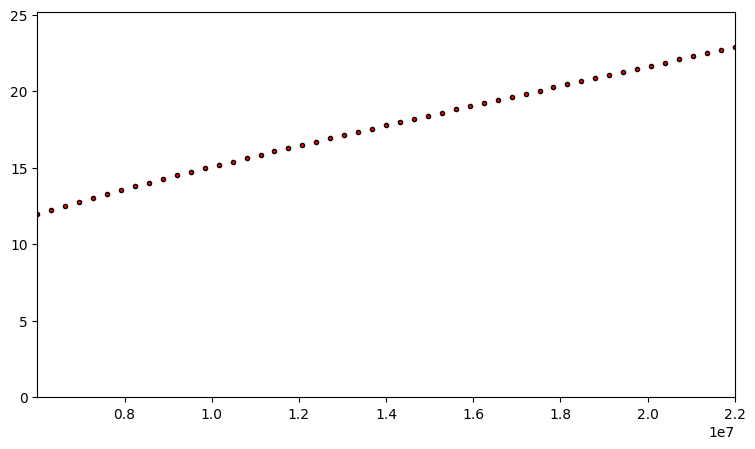

In [24]:
f_Ch1=res1[0]

phase_diff=res1[2]


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    f_Ch1,phase_diff,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)
    
ax.set_xlim(np.min(f_Ch1),np.max(f_Ch1))
ax.set_ylim(0,np.max(phase_diff)+0.1*np.max(phase_diff))
#plt.title(f"Power Stability\n Mean={mean:.2f} Std={std:.2f}")
plt.show()

In [25]:
laser.laser_OFF()

'1'

In [26]:
client.close()

In [27]:
gen.close()